In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# Lorenz System

The **Lorenz system** is the textbook example of deterministic chaos — a three-variable flow originally derived as a truncated model of atmospheric convection:

$$\dot x = \sigma(y - x),\qquad \dot y = x(\rho - z) - y,\qquad \dot z = xy - \beta z.$$

At the classic parameters $(\sigma, \rho, \beta) = (10, 28, 8/3)$ the trajectory settles onto the famous butterfly-shaped strange attractor with a positive Lyapunov exponent, so nearby trajectories diverge exponentially. In brainmass it serves as a chaotic integration / coupling test fixture. **Note:** use `dt = 0.01 * u.ms` (one natural time unit = 1 ms).

**Reference:** Lorenz (1963), *Deterministic nonperiodic flow*, Journal of the Atmospheric Sciences 20(2):130-141.

## Build the model

In [2]:
node = brainmass.LorenzStep(in_size=1, sigma=10.0, rho=28.0)
node

LorenzStep(
  in_size=(1,),
  out_size=(1,),
  sigma=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(10., dtype=float32)
  ),
  rho=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(28., dtype=float32)
  ),
  beta=Const(
    fit=False,
    t=IdentityT(),
    reg=None,
    val=Array(2.6666667, dtype=float32)
  ),
  init_x=Constant(value=1.0),
  init_y=Constant(value=1.0),
  init_z=Constant(value=1.0),
  method=exp_euler
)

## Run a simulation

Lorenz uses the fast `dt = 0.01 * u.ms` clock.

In [3]:
sim = brainmass.Simulator(node, dt=0.01 * u.ms)
res = sim.run(40. * u.ms, monitors=['x', 'y', 'z'], transient=2. * u.ms)
res['x'].shape

(3800, 1)

## Visualize

Left: the chaotic `x(t)` time series. Right: the butterfly attractor in the `x`-`z` plane.

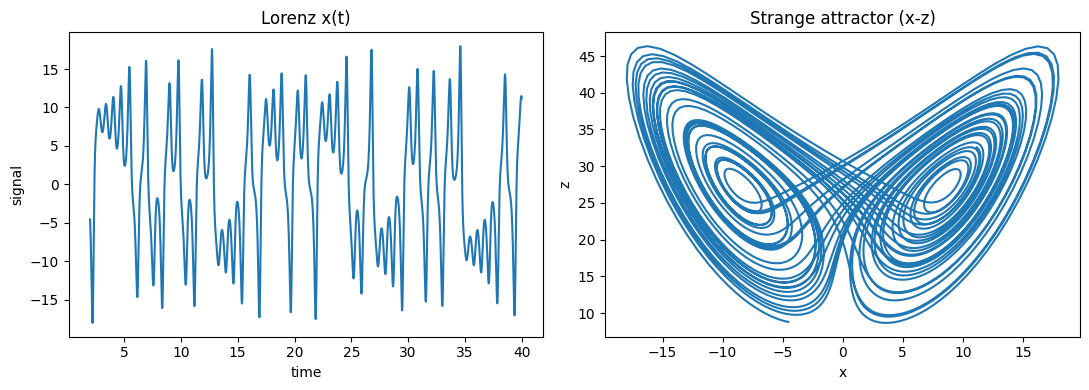

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
brainmass.viz.plot_timeseries(res['x'], ts=res['ts'], ax=axes[0])
axes[0].set_title('Lorenz x(t)')
brainmass.viz.plot_phase_portrait(res['x'], res['z'], ax=axes[1])
axes[1].set_xlabel('x'); axes[1].set_ylabel('z')
axes[1].set_title('Strange attractor (x-z)')
plt.tight_layout()
plt.show()

## Try it: sensitive dependence on initial conditions

The hallmark of chaos: two trajectories started a hair apart diverge exponentially. We perturb the initial `x` by `1e-3` and plot the growing separation.

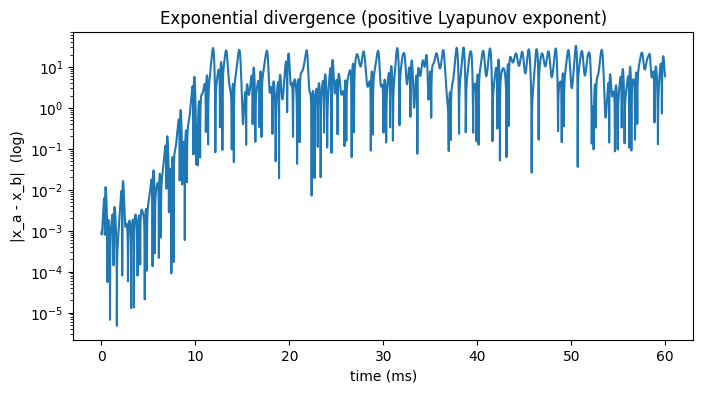

In [5]:
def run_from(x0):
    m = brainmass.LorenzStep(in_size=1, sigma=10.0, rho=28.0)
    brainstate.nn.init_all_states(m)
    m.x.value = m.x.value + x0
    return u.get_magnitude(
        brainmass.Simulator(m, dt=0.01 * u.ms).run(
            60. * u.ms, monitors=['x'], init_states=False)['x'])[:, 0]

a = run_from(0.0)
b = run_from(1e-3)
ts = np.arange(a.shape[0]) * 0.01
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(ts, np.abs(a - b) + 1e-12)
ax.set_xlabel('time (ms)'); ax.set_ylabel('|x_a - x_b|  (log)')
ax.set_title('Exponential divergence (positive Lyapunov exponent)')
plt.show()